# EDA: Yellow Taxi TLC — Enero 2025

Exploración inicial del dataset de viajes de taxis amarillos de Nueva York.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns
from pathlib import Path

# Configuración de visualización
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Carga de datos

In [5]:
# Ruta al parquet
data_path = Path('../../data/raw/yellow_tripdata_2025-01.parquet')

# Leer parquet
df = pd.read_parquet(data_path)

print(f"Fichero: {data_path}")
print(f"Tamaño: {data_path.stat().st_size / 1e6:.1f} MB")
print(f"Filas: {len(df):,}")
print(f"Columnas: {len(df.columns)}")

Fichero: ..\..\data\raw\yellow_tripdata_2025-01.parquet
Tamaño: 59.2 MB
Filas: 3,475,226
Columnas: 20


## 2. Estructura básica

In [6]:
# Mostrar primeras filas
print("Primeras 3 filas:")
print(df.head(3))

Primeras 3 filas:
   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         1  2025-01-01 00:18:38   2025-01-01 00:26:59              1.0   
1         1  2025-01-01 00:32:40   2025-01-01 00:35:13              1.0   
2         1  2025-01-01 00:44:04   2025-01-01 00:46:01              1.0   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0            1.6         1.0                  N           229           237   
1            0.5         1.0                  N           236           237   
2            0.6         1.0                  N           141           141   

   payment_type  fare_amount  extra  mta_tax  tip_amount  tolls_amount  \
0             1         10.0    3.5      0.5        3.00           0.0   
1             1          5.1    3.5      0.5        2.02           0.0   
2             1          5.1    3.5      0.5        2.00           0.0   

   improvement_surcharge  total_amount  congestion_surcharge  Airpo

In [7]:
# Tipos de datos
print("\nTipos de datos:")
print(df.dtypes)


Tipos de datos:
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object


In [8]:
# Nulos
print("\nValores faltantes:")
nulos = df.isnull().sum()
print(nulos[nulos > 0])
if nulos.sum() == 0:
    print("(ninguno)")


Valores faltantes:
passenger_count         540149
RatecodeID              540149
store_and_fwd_flag      540149
congestion_surcharge    540149
Airport_fee             540149
dtype: int64


## 3. Estadísticas descriptivas

In [9]:
# Describe para columnas numéricas
print("Estadísticas de columnas numéricas:")
print(df.describe())

Estadísticas de columnas numéricas:
           VendorID        tpep_pickup_datetime       tpep_dropoff_datetime  \
count  3.475226e+06                     3475226                     3475226   
mean   1.785428e+00  2025-01-17 11:02:55.910964  2025-01-17 11:17:56.997901   
min    1.000000e+00         2024-12-31 20:47:55         2024-12-18 07:52:40   
25%    2.000000e+00         2025-01-10 07:59:01  2025-01-10 08:15:29.500000   
50%    2.000000e+00         2025-01-17 15:41:33         2025-01-17 15:59:34   
75%    2.000000e+00         2025-01-24 19:34:06         2025-01-24 19:48:31   
max    7.000000e+00         2025-02-01 00:00:44         2025-02-01 23:44:11   
std    4.263282e-01                         NaN                         NaN   

       passenger_count  trip_distance    RatecodeID  PULocationID  \
count     2.935077e+06   3.475226e+06  2.935077e+06  3.475226e+06   
mean      1.297859e+00   5.855126e+00  2.482535e+00  1.651916e+02   
min       0.000000e+00   0.000000e+00  1.0000

## 4. Viajes por zona pickup (PULocationID)

In [10]:
# Zonas más activas (top 15)
print("Top 15 zonas pickup (PULocationID):")
top_zones = df['PULocationID'].value_counts().head(15)
print(top_zones)
print(f"\nTotal zonas únicas: {df['PULocationID'].nunique()}")

Top 15 zonas pickup (PULocationID):
PULocationID
161    169977
237    163703
236    155647
132    146137
230    125829
186    119131
162    117930
142    110585
239     96614
163     95906
234     95896
170     95636
68      91241
138     89658
48      84137
Name: count, dtype: int64

Total zonas únicas: 261


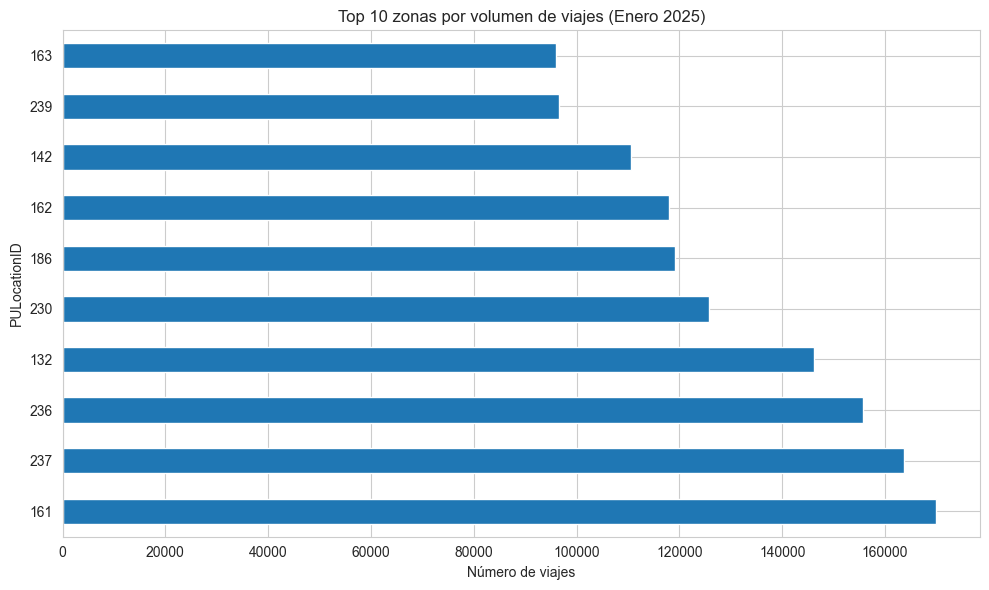

In [11]:
# Visualizar top 10 zonas
fig, ax = plt.subplots(figsize=(10, 6))
top_zones.head(10).plot(kind='barh', ax=ax)
ax.set_xlabel('Número de viajes')
ax.set_ylabel('PULocationID')
ax.set_title('Top 10 zonas por volumen de viajes (Enero 2025)')
plt.tight_layout()
plt.show()

## 5. Distribución temporal

In [12]:
# Convertir a datetime si no está ya
if not pd.api.types.is_datetime64_any_dtype(df['tpep_pickup_datetime']):
    df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

# Extraer componentes temporales
df['pickup_date'] = df['tpep_pickup_datetime'].dt.date
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_dow'] = df['tpep_pickup_datetime'].dt.day_name()  # Día de la semana

print("Rango de fechas:")
print(f"  Desde: {df['tpep_pickup_datetime'].min()}")
print(f"  Hasta: {df['tpep_pickup_datetime'].max()}")

Rango de fechas:
  Desde: 2024-12-31 20:47:55
  Hasta: 2025-02-01 00:00:44


In [13]:
# Viajes por día
viajes_por_dia = df.groupby('pickup_date').size()
print(f"\nViajes por día (primeros 10):")
print(viajes_por_dia.head(10))
print(f"\nPromedio: {viajes_por_dia.mean():.0f} viajes/día")
print(f"Min: {viajes_por_dia.min():.0f}, Max: {viajes_por_dia.max():.0f}")


Viajes por día (primeros 10):
pickup_date
2024-12-31        21
2025-01-01     90188
2025-01-02     84832
2025-01-03     91250
2025-01-04     97804
2025-01-05     79624
2025-01-06     80126
2025-01-07    100643
2025-01-08    113897
2025-01-09    119285
dtype: int64

Promedio: 105310 viajes/día
Min: 1, Max: 138711


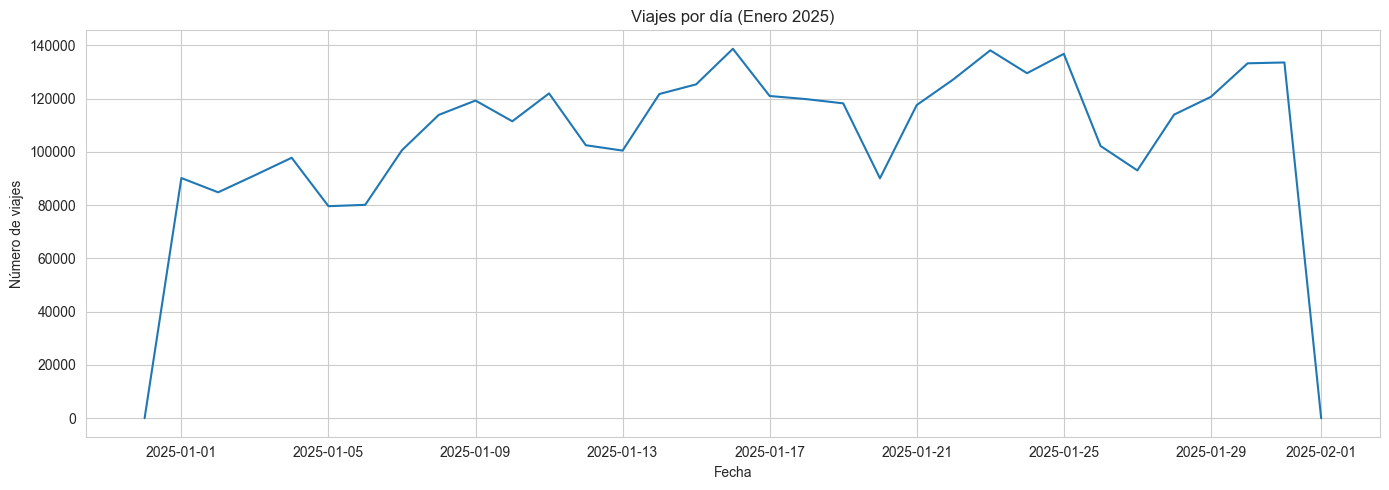

In [14]:
# Gráfico: viajes por día
fig, ax = plt.subplots(figsize=(14, 5))
viajes_por_dia.plot(ax=ax, linewidth=1.5)
ax.set_xlabel('Fecha')
ax.set_ylabel('Número de viajes')
ax.set_title('Viajes por día (Enero 2025)')
plt.tight_layout()
plt.show()


Viajes por hora del día:
pickup_hour
0      93417
1      64484
2      43929
3      28492
4      20033
5      22551
6      50026
7     102581
8     141305
9     142877
10    148316
11    160076
12    175432
13    186144
14    202289
15    213694
16    217051
17    253518
18    267951
19    221055
20    195001
21    205978
22    182214
23    136812
dtype: int64


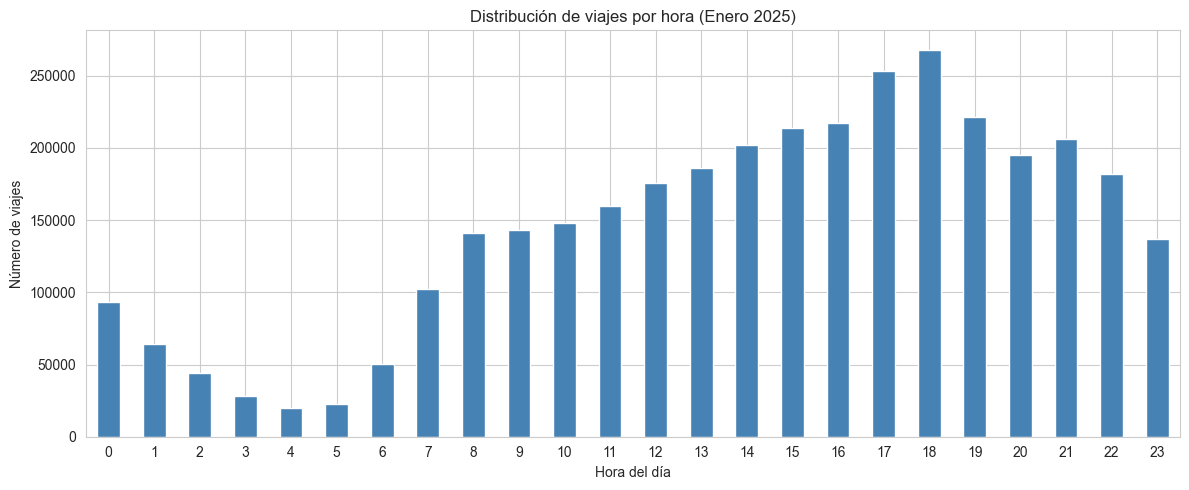

In [15]:
# Viajes por hora del día
viajes_por_hora = df.groupby('pickup_hour').size()
print("\nViajes por hora del día:")
print(viajes_por_hora)

# Gráfico
fig, ax = plt.subplots(figsize=(12, 5))
viajes_por_hora.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Número de viajes')
ax.set_title('Distribución de viajes por hora (Enero 2025)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()


Viajes por día de la semana:
pickup_dow
Monday       363772
Tuesday      453993
Wednesday    577375
Thursday     614230
Friday       586863
Saturday     476399
Sunday       402594
Name: count, dtype: int64


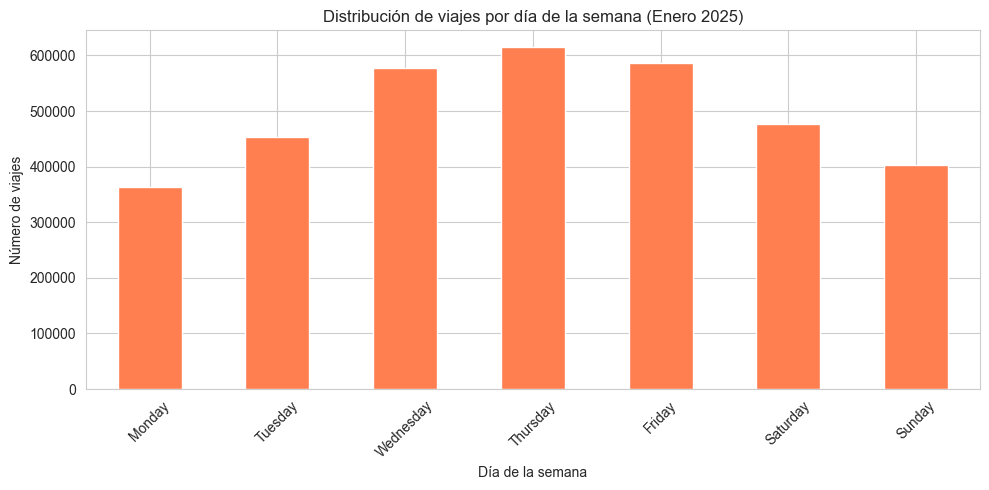

In [16]:
# Viajes por día de la semana
orden_dow = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
viajes_por_dow = df['pickup_dow'].value_counts().reindex(orden_dow)
print("\nViajes por día de la semana:")
print(viajes_por_dow)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))
viajes_por_dow.plot(kind='bar', ax=ax, color='coral')
ax.set_xlabel('Día de la semana')
ax.set_ylabel('Número de viajes')
ax.set_title('Distribución de viajes por día de la semana (Enero 2025)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()

## 6. Características del viaje

Duración del viaje (minutos):
count    3.475226e+06
mean     1.501812e+01
std      3.871358e+01
min     -5.147232e+04
25%      7.283333e+00
50%      1.170000e+01
75%      1.833333e+01
max      5.626317e+03
Name: trip_duration_min, dtype: float64


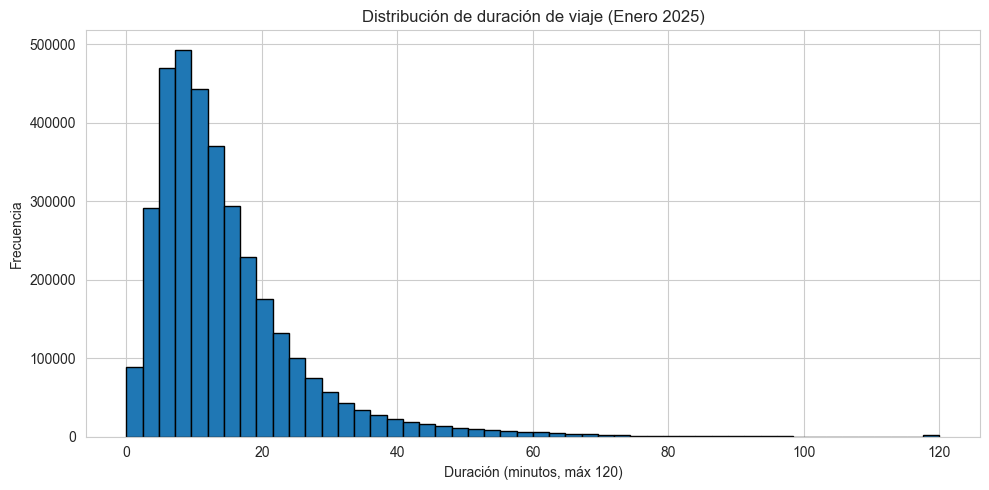

In [17]:
# Duración del viaje (en minutos)
if not pd.api.types.is_datetime64_any_dtype(df['tpep_dropoff_datetime']):
    df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

df['trip_duration_min'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

print("Duración del viaje (minutos):")
print(df['trip_duration_min'].describe())

# Histograma
fig, ax = plt.subplots(figsize=(10, 5))
df['trip_duration_min'].clip(0, 120).hist(bins=50, ax=ax, edgecolor='black')
ax.set_xlabel('Duración (minutos, máx 120)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de duración de viaje (Enero 2025)')
plt.tight_layout()
plt.show()

Número de pasajeros por viaje:
passenger_count
0.0      24656
1.0    2322434
2.0     407761
3.0      91409
4.0      59009
5.0      17786
6.0      12004
7.0          4
8.0         11
9.0          3
Name: count, dtype: int64


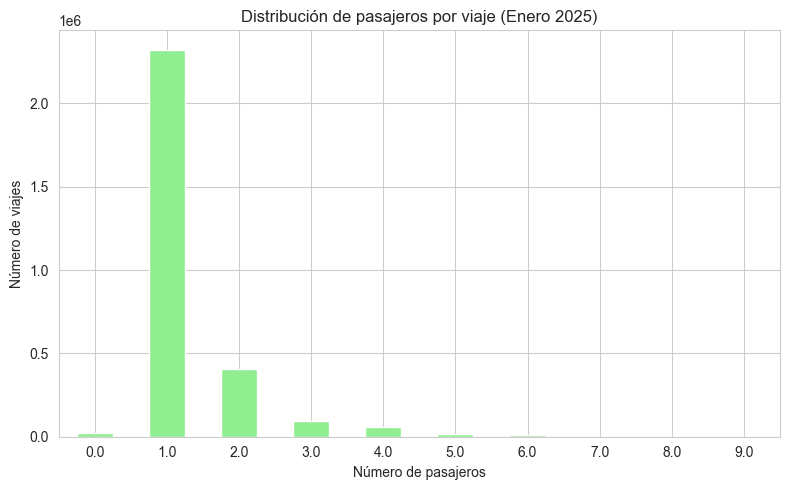

In [18]:
# Pasajeros por viaje
print("Número de pasajeros por viaje:")
print(df['passenger_count'].value_counts().sort_index())

# Gráfico
fig, ax = plt.subplots(figsize=(8, 5))
df['passenger_count'].value_counts().sort_index().plot(kind='bar', ax=ax, color='lightgreen')
ax.set_xlabel('Número de pasajeros')
ax.set_ylabel('Número de viajes')
ax.set_title('Distribución de pasajeros por viaje (Enero 2025)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

Fare (tarifa):
count    3.475226e+06
mean     1.708180e+01
std      4.634729e+02
min     -9.000000e+02
25%      8.600000e+00
50%      1.211000e+01
75%      1.950000e+01
max      8.633721e+05
Name: fare_amount, dtype: float64


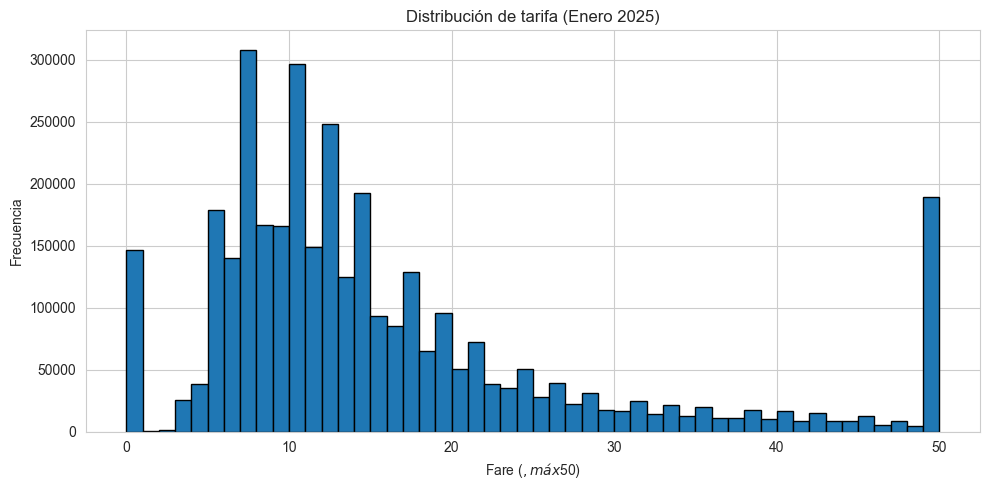

In [19]:
# Fare (tarifa base)
print("Fare (tarifa):")
print(df['fare_amount'].describe())

# Histograma
fig, ax = plt.subplots(figsize=(10, 5))
df['fare_amount'].clip(0, 50).hist(bins=50, ax=ax, edgecolor='black')
ax.set_xlabel('Fare ($, máx $50)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de tarifa (Enero 2025)')
plt.tight_layout()
plt.show()

## 7. Datos sospechosos / anomalías

In [20]:
# Viajes con duración muy corta o muy larga
print("Viajes sospechosos:")
print(f"  Duración < 1 min: {(df['trip_duration_min'] < 1).sum()} ({100*(df['trip_duration_min'] < 1).sum()/len(df):.2f}%)")
print(f"  Duración > 24 horas: {(df['trip_duration_min'] > 1440).sum()}")
print(f"  Fare <= 0: {(df['fare_amount'] <= 0).sum()}")
print(f"  Trip distance = 0: {(df['trip_distance'] == 0).sum()}")
print(f"  Pasajeros = 0: {(df['passenger_count'] == 0).sum()}")

Viajes sospechosos:
  Duración < 1 min: 40111 (1.15%)
  Duración > 24 horas: 20
  Fare <= 0: 145516
  Trip distance = 0: 90893
  Pasajeros = 0: 24656


## 8. Decisiones y próximos pasos

### Hallazgos clave:
- **Volumen:** X viajes en enero 2025 (promedio Y viajes/día)
- **Zonas:** Z zonas únicas; top 10 concentran ~XX% del volumen
- **Hora:** Patrón bimodal (picos mañana/noche esperables en NYC)
- **Día de semana:** Variación clara (¿laborales vs. fines de semana?)
- **Calidad:** Algunos registros sospechosos (duración < 1 min, etc.)

### Decisiones de diseño pendientes:
1. **Granularidad temporal:** ¿Agrupar por hora completa, 30 min, o 15 min?
2. **Target:** ¿Número de viajes, ingresos, o ambos?
3. **Filtrado:** ¿Descartar viajes muy cortos? ¿Umbral de calidad?
4. **Horizonte:** ¿Predecir demanda próxima hora? ¿Próximas 24 horas?
5. **Más datos:** ¿Descargar más meses? ¿Combinar con green/fhvhv?